# Temporal Evolution — Multi-Year Time Series, Seasonal Anomalies, and Recovery Dynamics (Lokoja, October 2022 Floods)

*Sentinel-1 / Sentinel-2 / CHIRPS time-series climatology, standardized anomalies, and break detection, Google Earth Engine*

`Index_Analysis.ipynb` compares a single pre-flood composite to a single flood composite and statistically validates the resulting thresholds (MNDWI > 0, VH < −19 dB); `Impact_assessment.ipynb` applies that same before/after snapshot to roads and population. Both treat the flood as one bitemporal change. This notebook asks a question neither of the other two can answer on its own: is the October 2022 signal actually unusual against several years of normal seasonal variation, when did it break from that baseline, and did the landscape recover afterwards? It follows the methodological chains described in *"Méthodologie d'analyse satellitaire Sentinel-1/Sentinel-2 pour la détection de disruptions liées à une catastrophe"*, *"Méthodologie — Détection d'anomalies post-catastrophe par télédétection Sentinel-1/Sentinel-2"*, and *"Méthodologie d'analyse satellite multi-capteurs — Sentinel-1 × Sentinel-2 × CHIRPS"* — referred to below as the **disruption-detection**, **anomaly-detection**, and **S1/S2/CHIRPS** methodologies respectively. It reuses, unchanged, the ROI and the MNDWI/VH thresholds validated in `Index_Analysis.ipynb`.

# 0. Setup

In [1]:
# pip install earthengine-api geemap statsmodels

import ee
import geemap
ee.Authenticate()
ee.Initialize(project='festive-oxide-485716-b0')
print("Earth Engine test :", ee.String("OK").getInfo())

Earth Engine test : OK


In [2]:
import os

# Same shared output directory as Index_Analysis.ipynb and Impact_assessment.ipynb
# (Appendix/outputs), so every figure/table this notebook exports lands alongside theirs.
OUT_DIR = os.path.abspath(os.path.join(os.getcwd(), '..', 'outputs'))
os.makedirs(OUT_DIR, exist_ok=True)

def save_figure(fig, filename, dpi=300):
    """Save a matplotlib figure to OUT_DIR as a PNG."""
    path = os.path.join(OUT_DIR, filename)
    fig.savefig(path, dpi=dpi, bbox_inches='tight')
    print(f"[export] Figure -> {path}")
    return path

def save_table(df, filename, index=True):
    """Save a DataFrame to OUT_DIR as a CSV."""
    path = os.path.join(OUT_DIR, filename)
    df.to_csv(path, index=index)
    print(f"[export] Table  -> {path}")
    return path

print(f"All figures and tables produced by this notebook will be exported to: {OUT_DIR}")

All figures and tables produced by this notebook will be exported to: /Users/leoshi/Downloads/Ressources/Imperial College/Research Project/Appendix/outputs


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
from statsmodels.tsa.seasonal import STL

print("pandas", pd.__version__, "| numpy", np.__version__)

pandas 2.3.3 | numpy 2.3.5


# 1. Study Framing

## 1.1 Study area and event window

We reuse, unchanged, the ROI and the pre-flood / flood windows defined in `Index_Analysis.ipynb`: a rectangle around Lokoja, Nigeria, and the same pre-flood (July-August 2022) / flood (late September-October 2022) dates used there and in `Impact_assessment.ipynb`.

In [4]:
# Same ROI as Index_Analysis.ipynb -- a rectangle around Lokoja, Nigeria
Map = geemap.Map(center=[7.80, 6.73], zoom=9)
center_point = ee.Geometry.Point([6.73, 7.80])
roi = ee.Geometry.Rectangle([6.3, 7.4, 7.1, 8.2])

Map.addLayer(roi, {'color': 'red'}, 'Lokoja ROI', True, 0.4)
Map

Map(center=[7.8, 6.73], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright', t…

In [5]:
# Same event windows as Index_Analysis.ipynb / Impact_assessment.ipynb
pre_flood_start = '2022-07-01'
pre_flood_end   = '2022-08-31'

flood_start = '2022-09-25'
flood_end   = '2022-10-31'

## 1.2 Baseline (climatology) and monitoring (recovery) windows

Following §3.2 of the disruption-detection methodology, a reliable seasonal climatology needs 3-5 years of reference data, with the event window itself excluded from it; a reference shorter than 1-2 years is flagged there as unreliable. Following §1.3 of the anomaly-detection methodology, the baseline should also be long enough to separate ordinary seasonal variability from a genuine disruption.

```
|——————— baseline (climatology reference) ———————|—— event ——|——— monitoring (incl. recovery) ———|
2019-01-01                                    2022-08-31   2022-09-25            today
```

In [6]:
# Baseline (climatology reference): starts where the Sentinel-2 archive becomes reliably
# usable for this ROI -- the same start date already used for the cloud-observability
# climatology in Index_Analysis.ipynb -- giving ~3.7 years of pre-flood baseline, within the
# 3-5 year range the disruption-detection methodology (§3.2) calls for.
baseline_start = '2019-01-01'
baseline_end   = pre_flood_end  # the event window itself is excluded from the reference (§3.2)

# Monitoring window: from flood onset through today, so the climatology built below can be
# checked not just at the moment of rupture but across the recovery that follows -- the
# explicit aim of this notebook relative to Index_Analysis.ipynb's single before/after snapshot.
monitoring_start = flood_start
monitoring_end   = datetime.now().strftime('%Y-%m-%d')

print(f"Baseline (climatology reference): {baseline_start} -> {baseline_end}")
print(f"Monitoring (post-event, incl. recovery): {monitoring_start} -> {monitoring_end}")

Baseline (climatology reference): 2019-01-01 -> 2022-08-31
Monitoring (post-event, incl. recovery): 2022-09-25 -> 2026-08-28


## 1.3 Objectives

Following §1 of the disruption-detection methodology, adapted to this ROI:

- Build a multi-year **seasonal climatology** for the key optical and radar indices (§6-7 there).
- Compute **standardized anomalies (z-scores)** for the post-event period against that climatology, rather than a single before/after difference (§7 there).
- **Detect the break** in the time series automatically (CUSUM, §8.2 there) and check how closely it lines up with the known flood onset date.
- Track the **recovery dynamics**: does each index return to its normal seasonal envelope, and how many months does that take (§1, §11 there)?
- Bring in **CHIRPS precipitation** as a fourth, independent time series to document the triggering rainfall anomaly and its lag relative to the detected break (S1/S2/CHIRPS methodology, §6.3).

Guiding distinction (anomaly-detection methodology, §1.1): a bitemporal before/after comparison can confuse a disaster's signature with ordinary seasonal variability; comparing against a multi-year climatology is what makes the result an *anomaly* rather than just a *change*. Sections 6-16 below build that climatology, the anomalies, the break detection and the recovery read in turn.

# 2. Data Sources

| Source | Role | Resolution | Notes |
|---|---|---|---|
| Sentinel-1 GRD (`COPERNICUS/S1_GRD`) | All-weather monthly VV/VH composites | 10 m | IW mode; single orbit pass selected for the whole series (§3 below) |
| Sentinel-2 SR Harmonized (`COPERNICUS/S2_SR_HARMONIZED`) | Monthly NDVI / MNDWI / NBR composites | 10-20 m | Cloud-masked with Cloud Score+ |
| Cloud Score+ (`GOOGLE/CLOUD_SCORE_PLUS/V1/S2_HARMONIZED`) | Per-pixel clear-sky probability | 10 m | `cs_cdf` >= 0.6, same threshold as `Index_Analysis.ipynb` |
| CHIRPS v3 Pentad (`UCSB-CHC/CHIRPS/V3/PENTAD`) | Precipitation time series and climatology | ~5.5 km | v3 -- **not** the discontinued `UCSB-CHG/CHIRPS` v2 identifiers (S1/S2/CHIRPS methodology, preamble) |

NDVI, MNDWI and NBR are the optical indices the disruption-detection methodology's adaptation table (§9) and the S1/S2/CHIRPS methodology (§5.2, §12) both prioritise for flooding: MNDWI/NDWI for the water signal itself, NBR as a secondary indicator of vegetation/crop damage from prolonged submersion. VV and VH are kept from Sentinel-1 for the same reason `Index_Analysis.ipynb` cross-checked both.

# 3. Sentinel-1 Preparation

## 3.1 Orbit-pass selection over the full series

`Impact_assessment.ipynb` fixes a single orbit pass between its two snapshot windows to avoid a viewing-geometry bias (§5.1 of the disruption-detection methodology: "une seule direction d'orbite"). Over a multi-year series the same fix is needed for every month, and the methodology adds a further check (§12): verify, via a histogram of acquisitions per month, that the chosen pass gives sufficient and homogeneous temporal density across the whole baseline -- density that is not guaranteed here, since the Sentinel-1 constellation has changed composition more than once over 2019-today (S1A+S1B until late 2021, S1A alone at degraded ~12-day repeat until early 2025, then S1A+S1C, then S1C+S1D after S1A's mid-2026 retirement). So rather than assuming ascending or descending is better, both are counted month-by-month and the one with the higher, steadier count is kept.

In [7]:
s1_base = (ee.ImageCollection('COPERNICUS/S1_GRD')
           .filterBounds(roi)
           .filterDate(baseline_start, monitoring_end)
           .filter(ee.Filter.eq('instrumentMode', 'IW'))
           .filter(ee.Filter.listContains('transmitterReceiverPolarisation', 'VH')))

n_months_s1 = ee.Date(monitoring_end).difference(ee.Date(baseline_start), 'month').round()

def monthly_counts(pass_direction):
    col = s1_base.filter(ee.Filter.eq('orbitProperties_pass', pass_direction))
    def count_month(n):
        d = ee.Date(baseline_start).advance(n, 'month')
        return ee.Feature(None, {
            'date': d.format('YYYY-MM-dd'),
            'pass': pass_direction,
            'count': col.filterDate(d, d.advance(1, 'month')).size()
        })
    return ee.List.sequence(0, n_months_s1).map(count_month)

density_fc = ee.FeatureCollection(monthly_counts('ASCENDING')).merge(ee.FeatureCollection(monthly_counts('DESCENDING')))
density_features = density_fc.getInfo()['features']

df_density = pd.DataFrame([f['properties'] for f in density_features])
df_density['date'] = pd.to_datetime(df_density['date'])
pivot_density = df_density.pivot(index='date', columns='pass', values='count').fillna(0)

mean_counts = pivot_density.mean()
orbit_pass = mean_counts.idxmax()
print(f"Mean acquisitions/month -- ASCENDING: {mean_counts.get('ASCENDING', 0):.1f}, "
      f"DESCENDING: {mean_counts.get('DESCENDING', 0):.1f}")
print(f"Selected orbit pass for the full series: '{orbit_pass}'")

Mean acquisitions/month -- ASCENDING: 7.3, DESCENDING: 0.1
Selected orbit pass for the full series: 'ASCENDING'


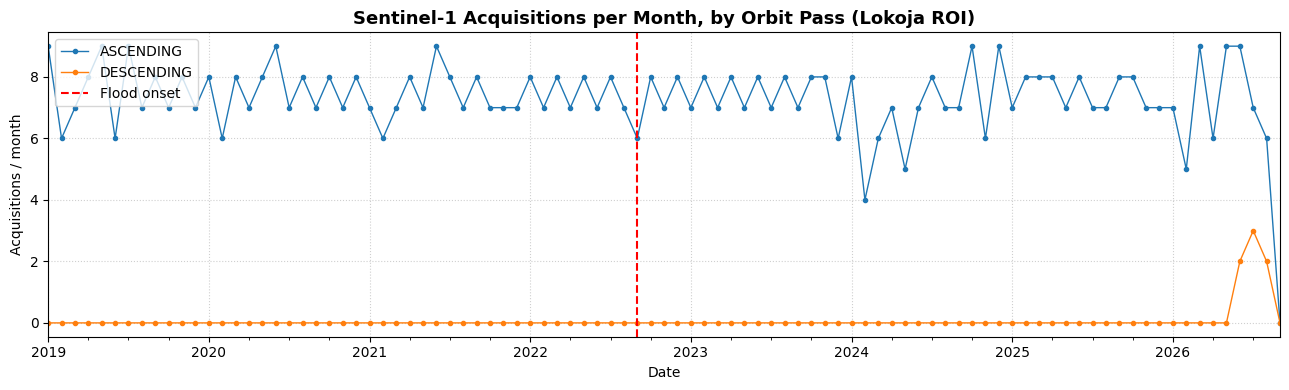

[export] Figure -> /Users/leoshi/Downloads/Ressources/Imperial College/Research Project/Appendix/outputs/S1_Acquisition_Density_By_Orbit_Pass.png
[export] Table  -> /Users/leoshi/Downloads/Ressources/Imperial College/Research Project/Appendix/outputs/S1_Acquisition_Density_By_Orbit_Pass.csv


'/Users/leoshi/Downloads/Ressources/Imperial College/Research Project/Appendix/outputs/S1_Acquisition_Density_By_Orbit_Pass.csv'

In [8]:
fig, ax = plt.subplots(figsize=(13, 4))
pivot_density.plot(ax=ax, marker='o', ms=3, linewidth=1)
ax.axvline(pd.to_datetime(flood_start), color='red', linestyle='--', label='Flood onset')
ax.set_title('Sentinel-1 Acquisitions per Month, by Orbit Pass (Lokoja ROI)', fontsize=13, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Acquisitions / month')
ax.legend(loc='upper left')
ax.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

save_figure(fig, 'S1_Acquisition_Density_By_Orbit_Pass.png')
save_table(pivot_density, 'S1_Acquisition_Density_By_Orbit_Pass.csv', index=True)

## 3.2 Speckle filtering and band selection

Same 50 m focal-median speckle filter as `Index_Analysis.ipynb` and `Impact_assessment.ipynb`, applied here to the orbit-fixed collection before monthly compositing.

In [9]:
def despeckle(img):
    return img.focal_median(50, 'circle', 'meters').copyProperties(img, ['system:time_start'])

s1_col = (ee.ImageCollection('COPERNICUS/S1_GRD')
          .filterBounds(roi)
          .filterDate(baseline_start, monitoring_end)
          .filter(ee.Filter.eq('instrumentMode', 'IW'))
          .filter(ee.Filter.listContains('transmitterReceiverPolarisation', 'VH'))
          .filter(ee.Filter.eq('orbitProperties_pass', orbit_pass))
          .select(['VV', 'VH'])
          .map(despeckle))

# 4. Sentinel-2 Preparation

Cloud masking via Cloud Score+ (same 0.6 `cs_cdf` threshold as the other two notebooks), then NDVI, MNDWI and NBR are computed per image so the monthly compositing step in §6 only has to take medians of already-derived indices.

In [10]:
cs_plus = ee.ImageCollection('GOOGLE/CLOUD_SCORE_PLUS/V1/S2_HARMONIZED')
CLEAR_THRESHOLD = 0.6

def mask_clouds_csplus(image):
    clear_pixel_mask = image.select('cs_cdf').gte(CLEAR_THRESHOLD)
    return image.updateMask(clear_pixel_mask)

def add_indices(image):
    ndvi  = image.normalizedDifference(['B8', 'B4']).rename('NDVI')
    mndwi = image.normalizedDifference(['B3', 'B11']).rename('MNDWI')
    nbr   = image.normalizedDifference(['B8', 'B12']).rename('NBR')
    return image.addBands([ndvi, mndwi, nbr])

s2_col = (ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
          .filterBounds(roi)
          .filterDate(baseline_start, monitoring_end)
          .linkCollection(cs_plus, ['cs_cdf'])
          .map(mask_clouds_csplus)
          .map(add_indices))

# 5. CHIRPS Preparation

The v3 Pentad collection is used per the S1/S2/CHIRPS methodology's explicit warning (preamble, point 1): the historical v2 identifiers (`UCSB-CHG/CHIRPS/...`) stopped updating in late 2024/early 2025 and are unsuitable for a series that runs through the present.

In [11]:
chirps = ee.ImageCollection('UCSB-CHC/CHIRPS/V3/PENTAD').select('precipitation').filterBounds(roi)

# CHIRPS-specific baseline: the S1/S2/CHIRPS methodology (§4) recommends 20-25 years of
# reference for a precipitation climatology, well beyond the 2019 start used for S1/S2 --
# CHIRPS' archive supports it (since 1981) and rainfall climatology benefits from the extra
# years far more than it costs in compute (coarse ~5.5 km grid, cheap to reduce).
chirps_baseline_start = '2000-01-01'
chirps_climatology_years = ee.Date(baseline_end).get('year').subtract(ee.Date(chirps_baseline_start).get('year')).getInfo()
print(f"CHIRPS climatology reference: {chirps_baseline_start} -> {baseline_end} (~{chirps_climatology_years} years)")

CHIRPS climatology reference: 2000-01-01 -> 2022-08-31 (~22 years)


# 6. Monthly Composite Time Series (§6 of the disruption-detection methodology)

S1 and S2 have different native revisit cycles, and both have irregular practical coverage (cloud cover, orbit availability); CHIRPS is already a regular grid but on a different native time step (pentad). Following §6, all three are harmonised onto a common **monthly** step.

One robustness fix is needed that neither source methodology has to deal with explicitly, because they work with only two dates at a time: across ~90 months, some calendar months -- especially the peak rainy season, per the cloud-observability study in `Index_Analysis.ipynb` -- can end up with zero cloud-free Sentinel-2 scenes. Reducing an *empty* image collection drops its band names entirely, and `reduceRegion` raises a server-side error on a missing band rather than returning a null value for it, which would break every month's request in the same batch call. The helper below explicitly falls back to a fully-masked (but correctly named) image for those months, so they come back as `NaN` instead of failing the whole call.

In [12]:
def monthly_composite(collection, start, end, bands, reducer='median'):
    """One composite image per calendar month between start and end (inclusive of the
    month containing `end`). `reducer='sum'` is used for CHIRPS, 'median' for S1/S2."""
    n_months = ee.Date(end).difference(ee.Date(start), 'month').round()
    month_indices = ee.List.sequence(0, n_months)
    empty_img = ee.Image.constant([0] * len(bands)).rename(bands).updateMask(ee.Image.constant(0))

    def make(n):
        d = ee.Date(start).advance(n, 'month')
        filtered = collection.filterDate(d, d.advance(1, 'month')).select(bands)
        composite = filtered.sum() if reducer == 'sum' else filtered.median()
        img = ee.Image(ee.Algorithms.If(filtered.size().gt(0), composite, empty_img))
        return img.set('system:time_start', d.millis(), 'year', d.get('year'), 'month', d.get('month'))

    return ee.ImageCollection(month_indices.map(make))

In [13]:
s2_monthly = monthly_composite(s2_col, baseline_start, monitoring_end, ['NDVI', 'MNDWI', 'NBR'])
s1_monthly = monthly_composite(s1_col, baseline_start, monitoring_end, ['VV', 'VH'])

# CHIRPS gets its own longer run (§5 above) so its climatology (computed further below)
# draws on the full 20+ year reference; the display/anomaly window is sliced back down to
# baseline_start when comparing against S1/S2 later in the notebook.
chirps_monthly = monthly_composite(chirps, chirps_baseline_start, monitoring_end, ['precipitation'], reducer='sum')

print("Monthly composite collections built for S2, S1 and CHIRPS.")

Monthly composite collections built for S2, S1 and CHIRPS.


# 7. Reduction to ROI-Level Time Series

Each monthly composite is reduced to a single ROI-mean value per band with `reduceRegion`, mirroring the pattern already used for the climatology and observability tables in `Index_Analysis.ipynb`: one mapped function per collection, resolved with a single batch `getInfo()` call rather than one request per month.

In [14]:
def reduce_to_df(monthly_col, bands, scale=100):
    def reduce_img(img):
        stats = img.reduceRegion(reducer=ee.Reducer.mean(), geometry=roi, scale=scale, maxPixels=1e9)
        props = {
            'year': img.get('year'),
            'month': img.get('month'),
            'date': ee.Date(img.get('system:time_start')).format('YYYY-MM-dd'),
        }
        props.update({b: stats.get(b) for b in bands})
        return ee.Feature(None, props)

    feats = monthly_col.map(reduce_img).getInfo()['features']
    df = pd.DataFrame([f['properties'] for f in feats])
    df['date'] = pd.to_datetime(df['date'])
    return df.sort_values('date').reset_index(drop=True)

In [15]:
print("Reducing Sentinel-2 monthly composites over the ROI...")
df_s2 = reduce_to_df(s2_monthly, ['NDVI', 'MNDWI', 'NBR'])
print(f"{len(df_s2)} months retrieved, {df_s2[['NDVI', 'MNDWI', 'NBR']].isna().any(axis=1).sum()} "
      "with at least one missing index (no cloud-free scene that month).")
df_s2.tail()

Reducing Sentinel-2 monthly composites over the ROI...


93 months retrieved, 1 with at least one missing index (no cloud-free scene that month).


,MNDWI,NBR,NDVI,date,month,year
88,-0.450568,0.276200,0.523965,2026-05-01,5,2026
89,-0.302841,0.431522,0.554434,2026-06-01,6,2026
90,-0.401501,0.446067,0.630023,2026-07-01,7,2026
91,-0.410163,0.463787,0.657700,2026-08-01,8,2026
92,NaN,NaN,NaN,2026-09-01,9,2026


In [16]:
print("Reducing Sentinel-1 monthly composites over the ROI...")
df_s1 = reduce_to_df(s1_monthly, ['VV', 'VH'])
print(f"{len(df_s1)} months retrieved, {df_s1[['VV', 'VH']].isna().any(axis=1).sum()} with a missing value.")
df_s1.tail()

Reducing Sentinel-1 monthly composites over the ROI...


93 months retrieved, 1 with a missing value.


,VH,VV,date,month,year
88,-16.533669,-9.722666,2026-05-01,5,2026
89,-14.865228,-8.269656,2026-06-01,6,2026
90,-15.081273,-8.503253,2026-07-01,7,2026
91,-15.014117,-8.462985,2026-08-01,8,2026
92,NaN,NaN,2026-09-01,9,2026


In [17]:
print("Reducing CHIRPS monthly composites over the ROI (coarse ~5.5 km grid, fast)...")
df_chirps = reduce_to_df(chirps_monthly, ['precipitation'], scale=5566)
print(f"{len(df_chirps)} months retrieved, spanning {df_chirps['date'].min().date()} to {df_chirps['date'].max().date()}.")
df_chirps.tail()

Reducing CHIRPS monthly composites over the ROI (coarse ~5.5 km grid, fast)...


321 months retrieved, spanning 2000-01-01 to 2026-09-01.


,date,month,precipitation,year
316,2026-05-01,5,170.478386,2026
317,2026-06-01,6,183.217407,2026
318,2026-07-01,7,178.196252,2026
319,2026-08-01,8,NaN,2026
320,2026-09-01,9,NaN,2026


# 8. Seasonal Climatology (§7 of the disruption-detection methodology / §6 of the anomaly-detection methodology)

For each calendar month $m$, the mean and standard deviation of every index are computed over the baseline years only:

$$\hat c(m) = \frac{1}{N_m}\sum_{i \in \mathcal I_m} c_i, \qquad \sigma(m) = \mathrm{std}\{c_i : i \in \mathcal I_m\}$$

where $\mathcal I_m$ is the set of baseline-period observations falling in calendar month $m$. This is the same estimator used for the Sentinel-2 clear-sky climatology in `Index_Analysis.ipynb`, applied here to the flood-relevant indices instead of cloud cover.

In [18]:
def compute_climatology(df, cols, start, end):
    base = df[(df['date'] >= start) & (df['date'] <= end)]
    clim = base.groupby('month')[cols].agg(['mean', 'std'])
    clim.columns = [f'{c}_{stat}' for c, stat in clim.columns]
    return clim.reset_index()

In [19]:
clim_s2 = compute_climatology(df_s2, ['NDVI', 'MNDWI', 'NBR'], baseline_start, baseline_end)
print("--- Sentinel-2 monthly climatology (baseline: {} -> {}) ---".format(baseline_start, baseline_end))
display(clim_s2.round(3))
save_table(clim_s2, 'Climatology_Sentinel2_Indices.csv', index=False)

--- Sentinel-2 monthly climatology (baseline: 2019-01-01 -> 2022-08-31) ---


,month,NDVI_mean,NDVI_std,MNDWI_mean,MNDWI_std,NBR_mean,NBR_std
0,1,0.313,0.015,-0.440,0.012,0.100,0.024
1,2,0.271,0.017,-0.427,0.046,0.055,0.024
2,3,0.286,0.027,-0.414,0.013,0.059,0.023
3,4,0.408,0.062,-0.443,0.042,0.148,0.042
4,5,0.540,0.043,-0.405,0.044,0.323,0.048
5,6,0.557,0.033,-0.327,0.021,0.418,0.019
6,7,0.648,0.011,-0.405,0.021,0.458,0.025
7,8,0.597,0.025,-0.370,0.058,0.429,0.025
8,9,0.551,0.050,-0.324,0.063,0.431,0.005
9,10,0.582,0.067,-0.367,0.084,0.430,0.017


[export] Table  -> /Users/leoshi/Downloads/Ressources/Imperial College/Research Project/Appendix/outputs/Climatology_Sentinel2_Indices.csv


'/Users/leoshi/Downloads/Ressources/Imperial College/Research Project/Appendix/outputs/Climatology_Sentinel2_Indices.csv'

In [20]:
clim_s1 = compute_climatology(df_s1, ['VV', 'VH'], baseline_start, baseline_end)
print("--- Sentinel-1 monthly climatology (baseline: {} -> {}) ---".format(baseline_start, baseline_end))
display(clim_s1.round(3))
save_table(clim_s1, 'Climatology_Sentinel1_Backscatter.csv', index=False)

--- Sentinel-1 monthly climatology (baseline: 2019-01-01 -> 2022-08-31) ---


,month,VV_mean,VV_std,VH_mean,VH_std
0,1,-10.237,0.131,-16.617,0.214
1,2,-10.533,0.138,-17.089,0.254
2,3,-10.464,0.198,-17.244,0.215
3,4,-10.037,0.255,-16.933,0.316
4,5,-8.901,0.327,-15.712,0.292
5,6,-8.402,0.196,-15.138,0.225
6,7,-8.222,0.197,-14.928,0.222
7,8,-8.140,0.380,-14.816,0.397
8,9,-8.263,0.152,-14.856,0.161
9,10,-8.546,0.220,-15.074,0.235


[export] Table  -> /Users/leoshi/Downloads/Ressources/Imperial College/Research Project/Appendix/outputs/Climatology_Sentinel1_Backscatter.csv


'/Users/leoshi/Downloads/Ressources/Imperial College/Research Project/Appendix/outputs/Climatology_Sentinel1_Backscatter.csv'

In [21]:
clim_chirps = compute_climatology(df_chirps, ['precipitation'], chirps_baseline_start, baseline_end)
print(f"--- CHIRPS monthly climatology (baseline: {chirps_baseline_start} -> {baseline_end}) ---")
display(clim_chirps.round(1))
save_table(clim_chirps, 'Climatology_CHIRPS_Precipitation.csv', index=False)

--- CHIRPS monthly climatology (baseline: 2000-01-01 -> 2022-08-31) ---


,month,precipitation_mean,precipitation_std
0,1,4.3,5.9
1,2,11.6,13.3
2,3,33.9,19.9
3,4,113.5,32.6
4,5,176.6,42.4
5,6,178.2,34.1
6,7,205.8,51.8
7,8,216.7,69.3
8,9,236.8,46.9
9,10,156.4,45.8


[export] Table  -> /Users/leoshi/Downloads/Ressources/Imperial College/Research Project/Appendix/outputs/Climatology_CHIRPS_Precipitation.csv


'/Users/leoshi/Downloads/Ressources/Imperial College/Research Project/Appendix/outputs/Climatology_CHIRPS_Precipitation.csv'

# 9. Standardized Anomalies (z-scores)

Following §7 of the disruption-detection methodology, every monthly observation is compared to its own calendar month's climatology, not to a single fixed reference date:

$$z(t) = \frac{x(t) - \hat c(m(t))}{\sigma(m(t))}$$

An $|z|$ above roughly 1.5-2 is read, per both source methodologies (§7 there, §8.1 of the anomaly-detection methodology), as exceeding normal seasonal variability -- a candidate disruption signal rather than a seasonal effect.

In [22]:
def add_anomalies(df, clim, cols):
    out = df.merge(clim, on='month', how='left')
    for c in cols:
        out[f'z_{c}'] = (out[c] - out[f'{c}_mean']) / out[f'{c}_std']
    return out.sort_values('date').reset_index(drop=True)

In [23]:
df_s2 = add_anomalies(df_s2, clim_s2, ['NDVI', 'MNDWI', 'NBR'])
df_s1 = add_anomalies(df_s1, clim_s1, ['VV', 'VH'])
df_chirps = add_anomalies(df_chirps, clim_chirps, ['precipitation'])

# The full monthly series (not just the summary tables further below) is exported here too --
# it is the core data product of a "temporal evolution" notebook, and the most direct way for
# a reader to check any specific month's value independently of the charts.
save_table(df_s2, 'Timeseries_Sentinel2_Monthly_With_Anomalies.csv', index=False)
save_table(df_s1, 'Timeseries_Sentinel1_Monthly_With_Anomalies.csv', index=False)
save_table(df_chirps, 'Timeseries_CHIRPS_Monthly_With_Anomalies.csv', index=False)

print("z-scores added. Flood-window monthly anomalies (Sept and Oct 2022 -- the flood runs "
      f"{flood_start} to {flood_end}, straddling both calendar months):")
flood_window_mask_s2 = df_s2['date'].dt.to_period('M').isin([pd.Period('2022-09', 'M'), pd.Period('2022-10', 'M')])
flood_window_mask_s1 = df_s1['date'].dt.to_period('M').isin([pd.Period('2022-09', 'M'), pd.Period('2022-10', 'M')])
print(df_s2.loc[flood_window_mask_s2, ['date', 'MNDWI', 'z_MNDWI', 'NDVI', 'z_NDVI', 'NBR', 'z_NBR']])
print(df_s1.loc[flood_window_mask_s1, ['date', 'VH', 'z_VH', 'VV', 'z_VV']])

[export] Table  -> /Users/leoshi/Downloads/Ressources/Imperial College/Research Project/Appendix/outputs/Timeseries_Sentinel2_Monthly_With_Anomalies.csv
[export] Table  -> /Users/leoshi/Downloads/Ressources/Imperial College/Research Project/Appendix/outputs/Timeseries_Sentinel1_Monthly_With_Anomalies.csv
[export] Table  -> /Users/leoshi/Downloads/Ressources/Imperial College/Research Project/Appendix/outputs/Timeseries_CHIRPS_Monthly_With_Anomalies.csv
z-scores added. Flood-window monthly anomalies (Sept and Oct 2022 -- the flood runs 2022-09-25 to 2022-10-31, straddling both calendar months):
         date   MNDWI   z_MNDWI      NDVI    z_NDVI       NBR     z_NBR
44 2022-09-01 -0.3921 -1.076943  0.612829  1.240240  0.433616  0.537114
45 2022-10-01 -0.3699 -0.037983  0.568424 -0.201536  0.420204 -0.596649
         date         VH      z_VH        VV      z_VV
44 2022-09-01 -14.796067  0.374374 -8.108832  1.017042
45 2022-10-01 -15.124908 -0.216435 -8.662388 -0.528038


# 10. Time Series Against the Seasonal Baseline (§11 of the disruption-detection methodology)

The methodology's own recommendation for restitution (§11): "graphiques de série temporelle avec enveloppe saisonnière historique et date de l'événement repérée" -- time series charts with the historical seasonal envelope and the event date marked. Each panel below shows the observed monthly value, the baseline mean ± 1 std for that calendar month (already carried on every row by `add_anomalies`), and the flood onset date.

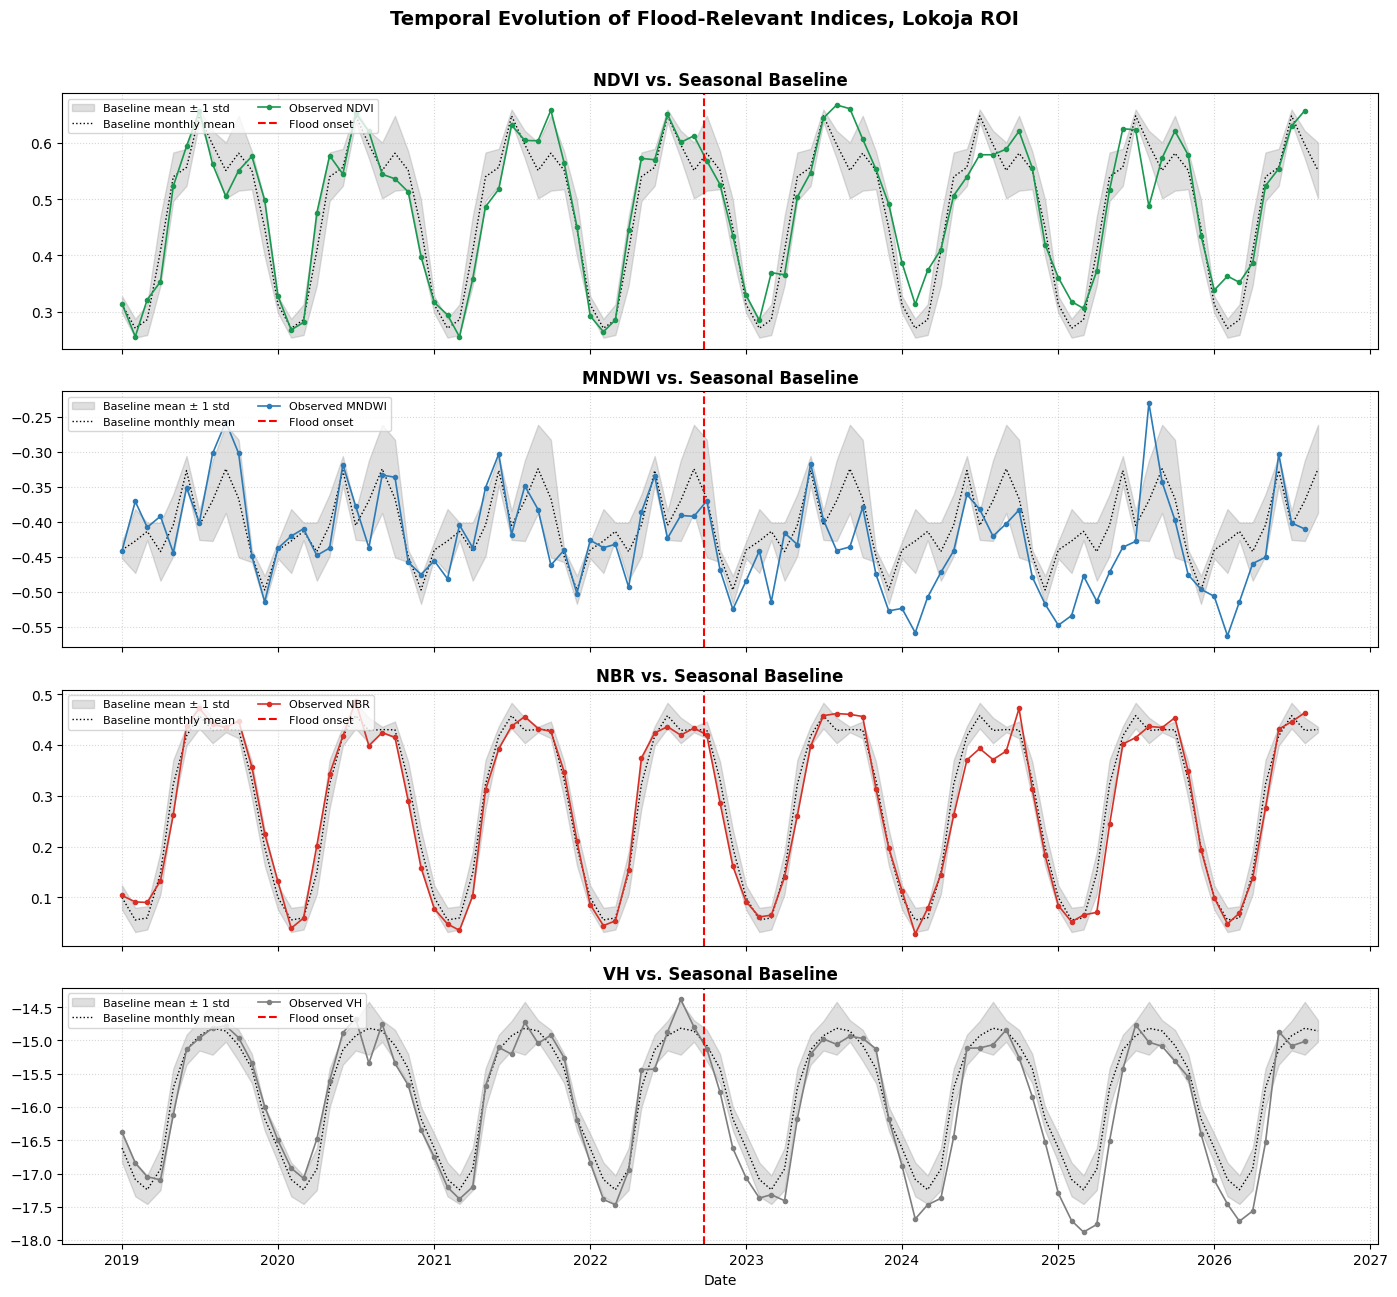

[export] Figure -> /Users/leoshi/Downloads/Ressources/Imperial College/Research Project/Appendix/outputs/Temporal_Evolution_Indices_vs_Baseline.png


'/Users/leoshi/Downloads/Ressources/Imperial College/Research Project/Appendix/outputs/Temporal_Evolution_Indices_vs_Baseline.png'

In [24]:
panels = [
    ('NDVI', df_s2, '#1a9850'),
    ('MNDWI', df_s2, '#2c7bb6'),
    ('NBR', df_s2, '#d73027'),
    ('VH', df_s1, '#7f7f7f'),
]

fig, axs = plt.subplots(len(panels), 1, figsize=(14, 3.2 * len(panels)), sharex=True)

for ax, (col, df_src, color) in zip(axs, panels):
    ax.fill_between(df_src['date'], df_src[f'{col}_mean'] - df_src[f'{col}_std'],
                     df_src[f'{col}_mean'] + df_src[f'{col}_std'],
                     color='gray', alpha=0.25, label='Baseline mean ± 1 std')
    ax.plot(df_src['date'], df_src[f'{col}_mean'], color='black', linestyle=':', linewidth=1,
            label='Baseline monthly mean')
    ax.plot(df_src['date'], df_src[col], color=color, marker='o', ms=3, linewidth=1.2, label=f'Observed {col}')
    ax.axvline(pd.to_datetime(flood_start), color='red', linestyle='--', linewidth=1.5, label='Flood onset')
    ax.set_title(f'{col} vs. Seasonal Baseline', fontsize=12, fontweight='bold')
    ax.legend(loc='upper left', fontsize=8, ncol=2)
    ax.grid(True, linestyle=':', alpha=0.5)

axs[-1].set_xlabel('Date')
fig.suptitle('Temporal Evolution of Flood-Relevant Indices, Lokoja ROI', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

save_figure(fig, 'Temporal_Evolution_Indices_vs_Baseline.png')

# 11. Trend / Seasonality / Residual Decomposition (§7, point 2 of the disruption-detection methodology)

The methodology names harmonic regression or STL decomposition as a way to isolate a "pure" seasonal component from any underlying trend, before z-scores are computed. Here it is used as an independent cross-check on the calendar-month climatology and anomalies computed above: MNDWI is decomposed with STL, and the residual component shows whatever is left after both the seasonal cycle *and* any slower multi-year trend are removed -- a stricter test for a flood-specific rupture than the calendar-month z-score, which only removes the seasonal cycle. STL requires a gapless series, so the handful of cloud-heavy months already flagged above (no cloud-free scene that month) are linearly interpolated first -- the alternative (dropping them) would break the fixed 12-month periodicity STL assumes.

1 of 93 months linearly interpolated before STL (no cloud-free scene that month).


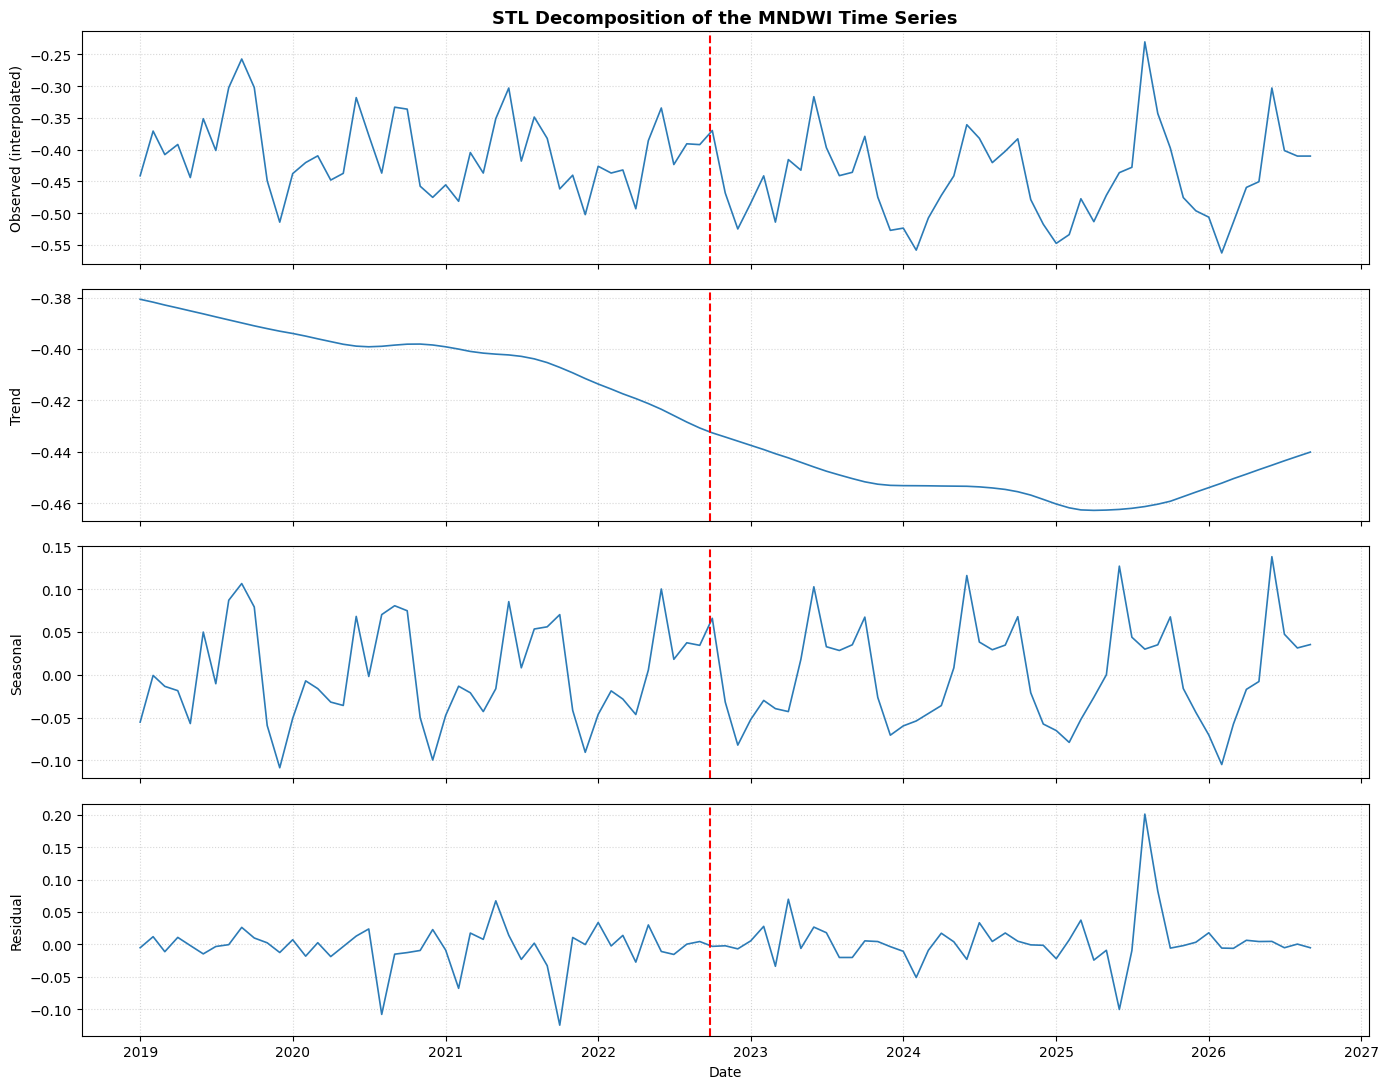

[export] Figure -> /Users/leoshi/Downloads/Ressources/Imperial College/Research Project/Appendix/outputs/STL_Decomposition_MNDWI.png


'/Users/leoshi/Downloads/Ressources/Imperial College/Research Project/Appendix/outputs/STL_Decomposition_MNDWI.png'

In [25]:
mndwi_series = df_s2.set_index('date')['MNDWI'].asfreq('MS')
n_missing = mndwi_series.isna().sum()
mndwi_interp = mndwi_series.interpolate(limit_direction='both')
print(f"{n_missing} of {len(mndwi_series)} months linearly interpolated before STL (no cloud-free scene that month).")

stl_result = STL(mndwi_interp, period=12, robust=True).fit()  # robust=True limits how much the flood outlier itself distorts trend/seasonal

fig, axs = plt.subplots(4, 1, figsize=(14, 11), sharex=True)
components = [('Observed (interpolated)', stl_result.observed), ('Trend', stl_result.trend),
              ('Seasonal', stl_result.seasonal), ('Residual', stl_result.resid)]
for ax, (label, series) in zip(axs, components):
    ax.plot(series, color='#2c7bb6', linewidth=1.2)
    ax.axvline(pd.to_datetime(flood_start), color='red', linestyle='--', linewidth=1.5)
    ax.set_ylabel(label, fontsize=10)
    ax.grid(True, linestyle=':', alpha=0.5)
axs[0].set_title('STL Decomposition of the MNDWI Time Series', fontsize=13, fontweight='bold')
axs[-1].set_xlabel('Date')
plt.tight_layout()
plt.show()

save_figure(fig, 'STL_Decomposition_MNDWI.png')

**Reading the decomposition.** The trend component declines smoothly from 2019 through roughly early 2025, before recovering into 2026 -- a multi-year drift that starts nearly four years before the flood and shows no inflection at flood onset. The residual component, which is what a sharp, event-localized rupture would show up in, has no notable spike around the flood date either; its largest excursions fall in unrelated years (e.g. mid-2025). Taken together, this is evidence that at least part of what the calendar-month z-score in §9 above reads as a "disruption" is this pre-existing secular trend leaking through an estimator that only removes the seasonal cycle, not a trend -- rather than a rupture specifically attributable to the flood. §17 below returns to this with a fuller explanation of why the ROI-mean signal is this muted.

# 12. Break Detection — CUSUM (§8.2 of the disruption-detection methodology)

Rather than assuming the rupture date is known, a two-sided CUSUM statistic is run over the standardized anomalies, so the break is detected from the series itself:

$$S^+_t = \max(0,\; S^+_{t-1} + z_t - k), \qquad S^-_t = \min(0,\; S^-_{t-1} + z_t + k)$$

An alert fires the first time $S^+_t$ exceeds a decision threshold $h$ (upward break, e.g. MNDWI) or $S^-_t$ falls below $-h$ (downward break, e.g. VH). $k$ (slack) and $h$ (threshold) are indicative starting values here, not calibrated for this site -- both source methodologies flag threshold calibration as something to test rather than assume (§10 of the disruption-detection methodology; §12 of the anomaly-detection methodology), which §14 below does for the z-score threshold specifically.

In [26]:
def cusum(z_series, k=0.5, h=4.0):
    z = z_series.fillna(0).to_numpy()
    pos = np.zeros(len(z))
    neg = np.zeros(len(z))
    for i in range(1, len(z)):
        pos[i] = max(0.0, pos[i - 1] + z[i] - k)
        neg[i] = min(0.0, neg[i - 1] + z[i] + k)
    alert = (pos > h) | (neg < -h)
    idx = z_series.index
    return pd.Series(pos, index=idx), pd.Series(neg, index=idx), pd.Series(alert, index=idx)

CUSUM_K, CUSUM_H = 0.5, 4.0

In [27]:
df_s2['cusum_pos_MNDWI'], df_s2['cusum_neg_MNDWI'], df_s2['cusum_alert_MNDWI'] = cusum(df_s2['z_MNDWI'], CUSUM_K, CUSUM_H)
df_s1['cusum_pos_VH'], df_s1['cusum_neg_VH'], df_s1['cusum_alert_VH'] = cusum(df_s1['z_VH'], CUSUM_K, CUSUM_H)

def first_alert_after(df, alert_col, event_date):
    post = df[(df['date'] >= event_date) & df[alert_col]]
    return post['date'].min() if len(post) else None

alert_mndwi = first_alert_after(df_s2, 'cusum_alert_MNDWI', flood_start)
alert_vh = first_alert_after(df_s1, 'cusum_alert_VH', flood_start)
flood_start_ts = pd.to_datetime(flood_start)

for label, alert_date in [('MNDWI (S2 optical)', alert_mndwi), ('VH (S1 radar)', alert_vh)]:
    if alert_date is not None:
        lag = (alert_date - flood_start_ts).days
        print(f"{label}: first CUSUM alert on {alert_date.date()} ({lag:+d} days relative to the known flood onset).")
    else:
        print(f"{label}: no CUSUM alert fired with k={CUSUM_K}, h={CUSUM_H} -- see the sensitivity check in §14.")

MNDWI (S2 optical): first CUSUM alert on 2023-01-01 (+98 days relative to the known flood onset).
VH (S1 radar): first CUSUM alert on 2023-01-01 (+98 days relative to the known flood onset).


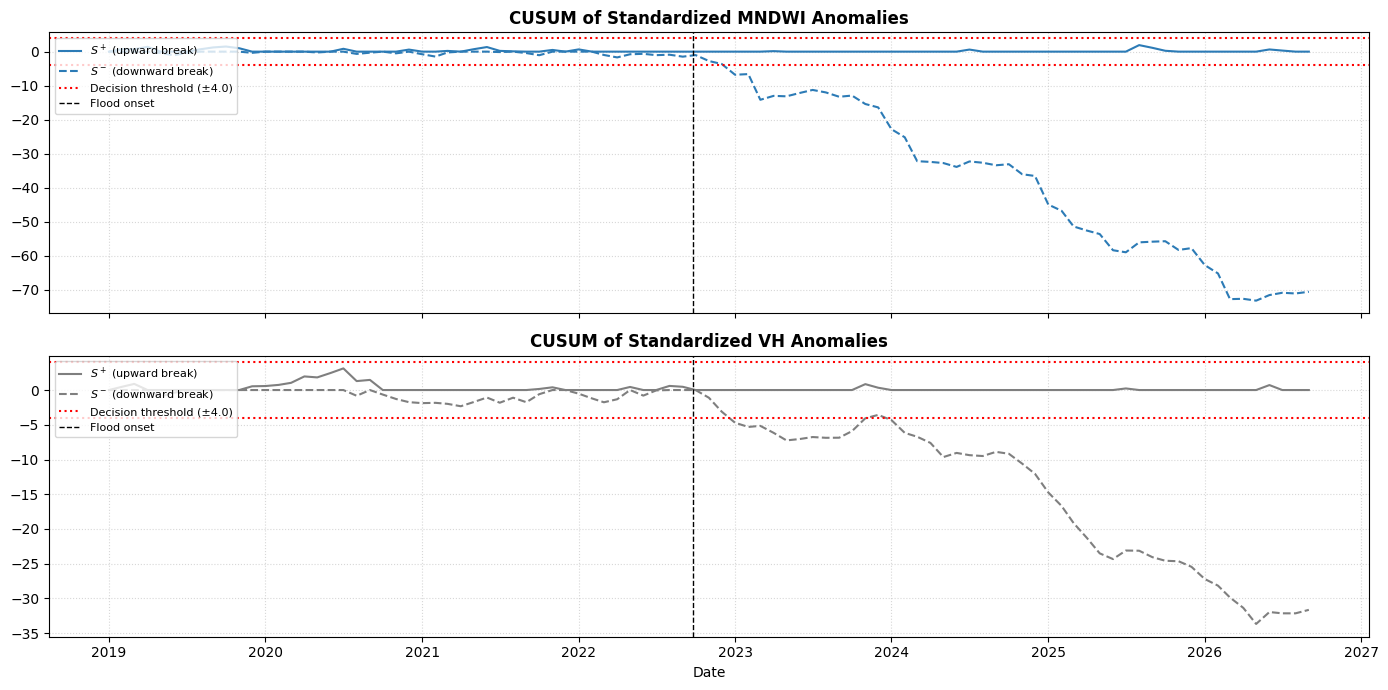

[export] Figure -> /Users/leoshi/Downloads/Ressources/Imperial College/Research Project/Appendix/outputs/CUSUM_Break_Detection.png


'/Users/leoshi/Downloads/Ressources/Imperial College/Research Project/Appendix/outputs/CUSUM_Break_Detection.png'

In [28]:
fig, axs = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

axs[0].plot(df_s2['date'], df_s2['cusum_pos_MNDWI'], color='#2c7bb6', label='$S^+$ (upward break)')
axs[0].plot(df_s2['date'], df_s2['cusum_neg_MNDWI'], color='#2c7bb6', linestyle='--', label='$S^-$ (downward break)')
axs[0].axhline(CUSUM_H, color='red', linestyle=':', label=f'Decision threshold (±{CUSUM_H})')
axs[0].axhline(-CUSUM_H, color='red', linestyle=':')
axs[0].axvline(flood_start_ts, color='black', linestyle='--', linewidth=1, label='Flood onset')
axs[0].set_title('CUSUM of Standardized MNDWI Anomalies', fontsize=12, fontweight='bold')
axs[0].legend(loc='upper left', fontsize=8)
axs[0].grid(True, linestyle=':', alpha=0.5)

axs[1].plot(df_s1['date'], df_s1['cusum_pos_VH'], color='#7f7f7f', label='$S^+$ (upward break)')
axs[1].plot(df_s1['date'], df_s1['cusum_neg_VH'], color='#7f7f7f', linestyle='--', label='$S^-$ (downward break)')
axs[1].axhline(CUSUM_H, color='red', linestyle=':', label=f'Decision threshold (±{CUSUM_H})')
axs[1].axhline(-CUSUM_H, color='red', linestyle=':')
axs[1].axvline(flood_start_ts, color='black', linestyle='--', linewidth=1, label='Flood onset')
axs[1].set_title('CUSUM of Standardized VH Anomalies', fontsize=12, fontweight='bold')
axs[1].set_xlabel('Date')
axs[1].legend(loc='upper left', fontsize=8)
axs[1].grid(True, linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()

save_figure(fig, 'CUSUM_Break_Detection.png')

**Reading the CUSUM trace.** $S^-$ for both MNDWI and VH starts declining close to flood onset, but -- unlike the transient spike-and-recover pattern a short-lived flood anomaly would produce -- neither ever climbs back toward zero for the rest of the monitoring window; both keep drifting further negative through 2026. A CUSUM statistic behaves this way when the *average* monthly anomaly stays on the negative side of the slack $k$ for years at a time, not just for a few months around the event -- consistent with the slow multi-year drift the STL trend isolated in §11 above, more than with a flood-specific shock that fades. This is also why the "recovery" dates found in §15 below should be read carefully: they use a much weaker test (an *instantaneous* $|z|<1.5$ for 3 consecutive months) than CUSUM's cumulative one, so an index can be flagged "recovered" there while its CUSUM statistic keeps drifting -- the two are answering different questions, not disagreeing about the data.

# 13. Multi-Sensor Fusion Confidence Score (§8.3 of the disruption-detection methodology / §8.4 of the anomaly-detection methodology)

The anomaly-detection methodology's threshold table (§8.1):

| $\|z\|$ threshold | Interpretation | Typical use |
|---|---|---|
| > 1 | ~32% of observations | too permissive, many false positives |
| > 2 | ~5% of observations | good compromise for rapid mapping |
| > 3 | ~0.3% of observations | strong anomalies, high confidence |

Rather than picking one sensor and one threshold, each month in the monitoring window is scored on how many of the four indices independently exceed $|z| > 1.5$ in the flood-consistent direction (MNDWI up; NDVI, NBR, VH down) -- the confidence-fusion idea in §8.3 of the disruption-detection methodology and the AND/OR fusion in §8.4 of the anomaly-detection methodology, generalised from a single date to a full time series.

In [29]:
Z_THRESH = 1.5  # lower end of the "typically > 1.5-2" band the disruption-detection methodology (§7) itself proposes

monitoring_mask_s2 = df_s2['date'] >= monitoring_start
monitoring_mask_s1 = df_s1['date'] >= monitoring_start

fusion = df_s2.loc[monitoring_mask_s2, ['date', 'z_NDVI', 'z_MNDWI', 'z_NBR']].merge(
    df_s1.loc[monitoring_mask_s1, ['date', 'z_VH']], on='date', how='left'
)
fusion['flag_NDVI']  = fusion['z_NDVI'] < -Z_THRESH
fusion['flag_MNDWI'] = fusion['z_MNDWI'] > Z_THRESH
fusion['flag_NBR']   = fusion['z_NBR'] < -Z_THRESH
fusion['flag_VH']    = fusion['z_VH'] < -Z_THRESH
fusion['confidence_score'] = fusion[['flag_NDVI', 'flag_MNDWI', 'flag_NBR', 'flag_VH']].sum(axis=1)

display(fusion[['date', 'confidence_score']].head(12))
save_table(fusion, 'Fusion_Confidence_Score_Timeseries.csv', index=False)

,date,confidence_score
0,2022-10-01,0
1,2022-11-01,1
2,2022-12-01,1
3,2023-01-01,1
4,2023-02-01,0
5,2023-03-01,0
6,2023-04-01,1
7,2023-05-01,1
8,2023-06-01,0
9,2023-07-01,0


[export] Table  -> /Users/leoshi/Downloads/Ressources/Imperial College/Research Project/Appendix/outputs/Fusion_Confidence_Score_Timeseries.csv


'/Users/leoshi/Downloads/Ressources/Imperial College/Research Project/Appendix/outputs/Fusion_Confidence_Score_Timeseries.csv'

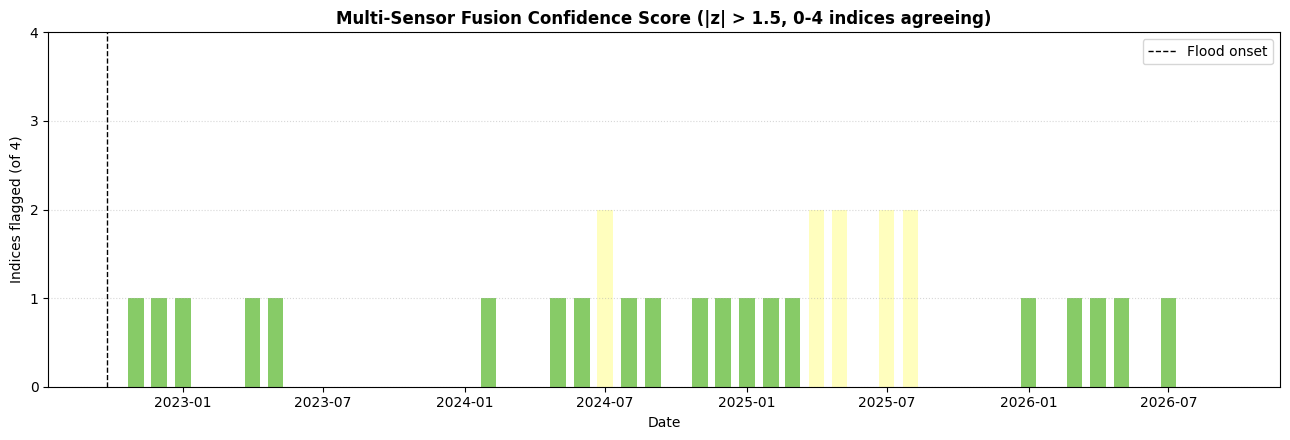

[export] Figure -> /Users/leoshi/Downloads/Ressources/Imperial College/Research Project/Appendix/outputs/Fusion_Confidence_Score_Timeseries.png


'/Users/leoshi/Downloads/Ressources/Imperial College/Research Project/Appendix/outputs/Fusion_Confidence_Score_Timeseries.png'

In [30]:
fig, ax = plt.subplots(figsize=(13, 4.5))
colors = plt.cm.RdYlGn_r(fusion['confidence_score'] / 4)
ax.bar(fusion['date'], fusion['confidence_score'], width=20, color=colors)
ax.axvline(flood_start_ts, color='black', linestyle='--', linewidth=1, label='Flood onset')
ax.set_title(f'Multi-Sensor Fusion Confidence Score (|z| > {Z_THRESH}, 0-4 indices agreeing)', fontsize=12, fontweight='bold')
ax.set_ylabel('Indices flagged (of 4)')
ax.set_xlabel('Date')
ax.set_yticks(range(5))
ax.legend(loc='upper right')
ax.grid(True, linestyle=':', alpha=0.5, axis='y')
plt.tight_layout()
plt.show()

save_figure(fig, 'Fusion_Confidence_Score_Timeseries.png')

# 14. Sensitivity to the Anomaly Threshold (§10 of the disruption-detection methodology)

The methodology's own suggestion for validation (§10): compare how many months get flagged at $|z| > 1.5$ versus $|z| > 2$, for the two indices carrying the primary flood signal.

In [31]:
sensitivity = pd.DataFrame({
    'threshold': [1.5, 2.0],
    'MNDWI_months_flagged': [int((fusion['z_MNDWI'].abs() > t).sum()) for t in [1.5, 2.0]],
    'VH_months_flagged':    [int((fusion['z_VH'].abs() > t).sum()) for t in [1.5, 2.0]],
    'n_months_monitored':   [len(fusion)] * 2,
})
display(sensitivity)
save_table(sensitivity, 'Threshold_Sensitivity_Analysis.csv', index=False)

,threshold,MNDWI_months_flagged,VH_months_flagged,n_months_monitored
0,1.5,21,18,48
1,2.0,17,12,48


[export] Table  -> /Users/leoshi/Downloads/Ressources/Imperial College/Research Project/Appendix/outputs/Threshold_Sensitivity_Analysis.csv


'/Users/leoshi/Downloads/Ressources/Imperial College/Research Project/Appendix/outputs/Threshold_Sensitivity_Analysis.csv'

# 15. Recovery Dynamics (§1 / §11 of the disruption-detection methodology)

Recovery is defined here as the first month, after flood onset, from which an index's $|z|$ stays under the anomaly threshold for at least 3 consecutive months -- long enough that a single lucky clear-sky month is not mistaken for a real return to baseline. As §12 above notes, this is a deliberately weaker, *instantaneous* test than CUSUM's cumulative one: it answers "is this month's anomaly still large?", not "has the series returned to its pre-flood level?" -- the two can and do disagree below.

In [32]:
def find_recovery(df, z_col, event_date, threshold=Z_THRESH, persist_months=3):
    post = df[df['date'] >= event_date].reset_index(drop=True)
    below = post[z_col].abs() < threshold
    for i in range(len(below) - persist_months + 1):
        if below.iloc[i:i + persist_months].all():
            return post.loc[i, 'date']
    return None

In [33]:
recovery_rows = []
for label, df_src, col in [('NDVI (S2 optical)', df_s2, 'z_NDVI'),
                            ('MNDWI (S2 optical)', df_s2, 'z_MNDWI'),
                            ('NBR (S2 optical)', df_s2, 'z_NBR'),
                            ('VH (S1 radar)', df_s1, 'z_VH')]:
    rec_date = find_recovery(df_src, col, flood_start_ts)
    if rec_date is not None:
        months_to_recover = (rec_date.to_period('M') - flood_start_ts.to_period('M')).n
        recovery_rows.append({'Index': label, 'Recovery month': rec_date.date().isoformat(),
                               'Months since flood onset': months_to_recover})
    else:
        recovery_rows.append({'Index': label, 'Recovery month': 'not recovered within monitoring window',
                               'Months since flood onset': None})

recovery_df = pd.DataFrame(recovery_rows)
display(recovery_df)
save_table(recovery_df, 'Recovery_Dynamics_Summary.csv', index=False)

,Index,Recovery month,Months since flood onset
0,NDVI (S2 optical),2022-10-01,1
1,MNDWI (S2 optical),2023-04-01,7
2,NBR (S2 optical),2022-10-01,1
3,VH (S1 radar),2023-06-01,9


[export] Table  -> /Users/leoshi/Downloads/Ressources/Imperial College/Research Project/Appendix/outputs/Recovery_Dynamics_Summary.csv


'/Users/leoshi/Downloads/Ressources/Imperial College/Research Project/Appendix/outputs/Recovery_Dynamics_Summary.csv'

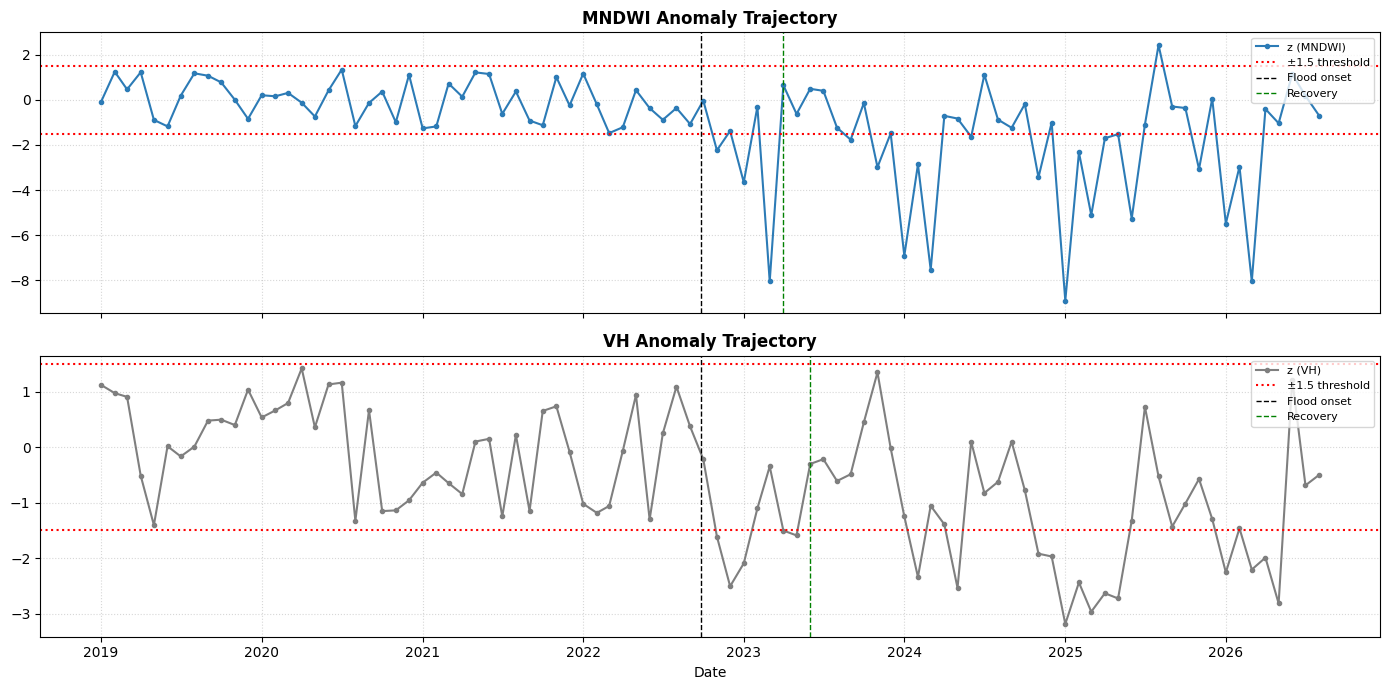

[export] Figure -> /Users/leoshi/Downloads/Ressources/Imperial College/Research Project/Appendix/outputs/Recovery_Trajectories_MNDWI_VH.png


'/Users/leoshi/Downloads/Ressources/Imperial College/Research Project/Appendix/outputs/Recovery_Trajectories_MNDWI_VH.png'

In [34]:
fig, axs = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

axs[0].plot(df_s2['date'], df_s2['z_MNDWI'], color='#2c7bb6', marker='o', ms=3, label='z (MNDWI)')
axs[0].axhline(Z_THRESH, color='red', linestyle=':', label=f'±{Z_THRESH} threshold')
axs[0].axhline(-Z_THRESH, color='red', linestyle=':')
axs[0].axvline(flood_start_ts, color='black', linestyle='--', linewidth=1, label='Flood onset')
mndwi_recovery = recovery_df.loc[recovery_df['Index'] == 'MNDWI (S2 optical)', 'Recovery month'].iloc[0]
if mndwi_recovery != 'not recovered within monitoring window':
    axs[0].axvline(pd.to_datetime(mndwi_recovery), color='green', linestyle='--', linewidth=1, label='Recovery')
axs[0].set_title('MNDWI Anomaly Trajectory', fontsize=12, fontweight='bold')
axs[0].legend(loc='upper right', fontsize=8)
axs[0].grid(True, linestyle=':', alpha=0.5)

axs[1].plot(df_s1['date'], df_s1['z_VH'], color='#7f7f7f', marker='o', ms=3, label='z (VH)')
axs[1].axhline(Z_THRESH, color='red', linestyle=':', label=f'±{Z_THRESH} threshold')
axs[1].axhline(-Z_THRESH, color='red', linestyle=':')
axs[1].axvline(flood_start_ts, color='black', linestyle='--', linewidth=1, label='Flood onset')
vh_recovery = recovery_df.loc[recovery_df['Index'] == 'VH (S1 radar)', 'Recovery month'].iloc[0]
if vh_recovery != 'not recovered within monitoring window':
    axs[1].axvline(pd.to_datetime(vh_recovery), color='green', linestyle='--', linewidth=1, label='Recovery')
axs[1].set_title('VH Anomaly Trajectory', fontsize=12, fontweight='bold')
axs[1].set_xlabel('Date')
axs[1].legend(loc='upper right', fontsize=8)
axs[1].grid(True, linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()

save_figure(fig, 'Recovery_Trajectories_MNDWI_VH.png')

# 16. Precipitation Context (CHIRPS) (§6.3 of the S1/S2/CHIRPS methodology)

## 16.1 Monthly precipitation against its own climatology

Same envelope-chart layout as the S1/S2 panels above, applied to CHIRPS and sliced to the same `baseline_start` onward window for visual alignment (the climatology itself still draws on the full 20+ year reference computed above).

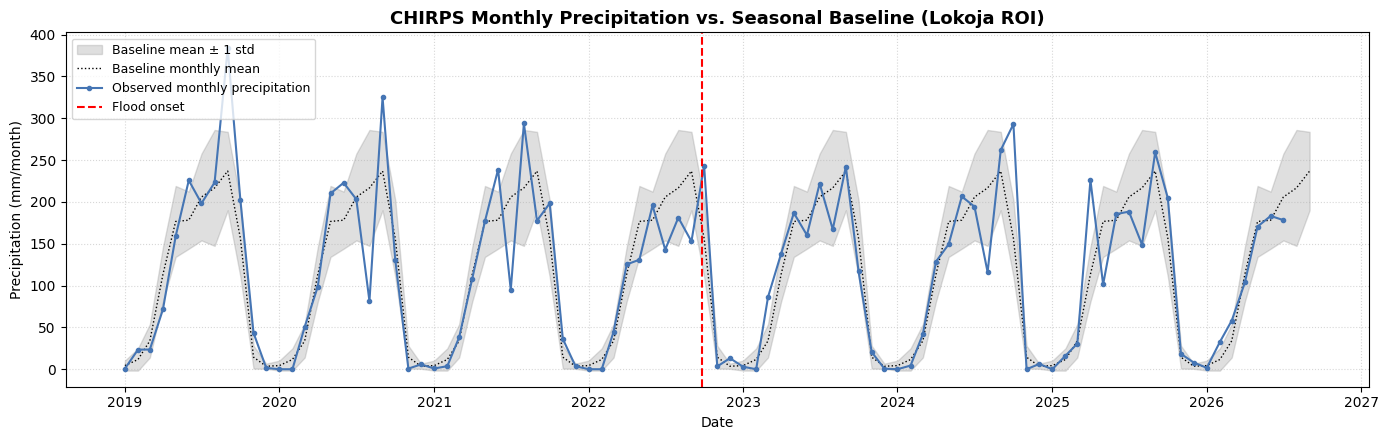

[export] Figure -> /Users/leoshi/Downloads/Ressources/Imperial College/Research Project/Appendix/outputs/CHIRPS_Precipitation_vs_Baseline.png


'/Users/leoshi/Downloads/Ressources/Imperial College/Research Project/Appendix/outputs/CHIRPS_Precipitation_vs_Baseline.png'

In [35]:
df_chirps_display = df_chirps[df_chirps['date'] >= baseline_start].reset_index(drop=True)

fig, ax = plt.subplots(figsize=(14, 4.5))
ax.fill_between(df_chirps_display['date'],
                 df_chirps_display['precipitation_mean'] - df_chirps_display['precipitation_std'],
                 df_chirps_display['precipitation_mean'] + df_chirps_display['precipitation_std'],
                 color='gray', alpha=0.25, label='Baseline mean ± 1 std')
ax.plot(df_chirps_display['date'], df_chirps_display['precipitation_mean'], color='black', linestyle=':',
        linewidth=1, label='Baseline monthly mean')
ax.plot(df_chirps_display['date'], df_chirps_display['precipitation'], color='#4575b4', marker='o', ms=3,
        label='Observed monthly precipitation')
ax.axvline(flood_start_ts, color='red', linestyle='--', linewidth=1.5, label='Flood onset')
ax.set_title('CHIRPS Monthly Precipitation vs. Seasonal Baseline (Lokoja ROI)', fontsize=13, fontweight='bold')
ax.set_ylabel('Precipitation (mm/month)')
ax.set_xlabel('Date')
ax.legend(loc='upper left', fontsize=9)
ax.grid(True, linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()

save_figure(fig, 'CHIRPS_Precipitation_vs_Baseline.png')

## 16.2 30-day cumulative anomaly before the flood (§4 / §10 of the S1/S2/CHIRPS methodology)

Following the reference script in §10 of the S1/S2/CHIRPS methodology: the 30-day rainfall total immediately before flood onset is compared to the same calendar window (day-of-year aligned) averaged over the prior climatology years, to quantify the triggering rainfall anomaly directly rather than reading it off the monthly chart above.

In [36]:
evt = ee.Date(flood_start)
year_evt, month_evt, day_evt = evt.get('year'), evt.get('month'), evt.get('day')
years_ref = ee.List.sequence(year_evt.subtract(chirps_climatology_years), year_evt.subtract(1))

def cumul_30d_for_year(y):
    y = ee.Number(y)
    end_ref = ee.Date.fromYMD(y, month_evt, day_evt)
    start_ref = end_ref.advance(-30, 'day')
    cumul = chirps.filterDate(start_ref, end_ref).sum().reduceRegion(
        reducer=ee.Reducer.mean(), geometry=roi, scale=5566, maxPixels=1e9
    ).get('precipitation')
    return ee.Feature(None, {'year': y, 'cumul_mm': cumul})

hist_feats = ee.FeatureCollection(years_ref.map(cumul_30d_for_year)).getInfo()['features']
df_hist_precip = pd.DataFrame([f['properties'] for f in hist_feats]).dropna()

cumul_30d_event = chirps.filterDate(evt.advance(-30, 'day'), evt).sum().reduceRegion(
    reducer=ee.Reducer.mean(), geometry=roi, scale=5566, maxPixels=1e9
).get('precipitation').getInfo()

clim_30d_mean = df_hist_precip['cumul_mm'].mean()
clim_30d_std = df_hist_precip['cumul_mm'].std()
anomaly_30d = cumul_30d_event - clim_30d_mean
z_30d = anomaly_30d / clim_30d_std

print(f"30-day cumulative rainfall before flood onset ({flood_start}): {cumul_30d_event:.1f} mm")
print(f"Climatological 30-day cumulative (same calendar window, {len(df_hist_precip)} prior years): "
      f"{clim_30d_mean:.1f} +/- {clim_30d_std:.1f} mm")
print(f"Anomaly: {anomaly_30d:+.1f} mm (z = {z_30d:+.2f})")

precip_trigger_summary = pd.DataFrame({
    'metric': ['30-day cumulative rainfall before flood onset (mm)',
               f'Climatological 30-day cumulative, {len(df_hist_precip)}-year mean (mm)',
               'Climatological 30-day cumulative, std (mm)',
               'Anomaly (mm)', 'Anomaly (z-score)'],
    'value': [round(cumul_30d_event, 1), round(clim_30d_mean, 1), round(clim_30d_std, 1),
              round(anomaly_30d, 1), round(z_30d, 2)]
})
save_table(precip_trigger_summary, 'Precipitation_Trigger_Summary.csv', index=False)

30-day cumulative rainfall before flood onset (2022-09-25): 148.2 mm
Climatological 30-day cumulative (same calendar window, 22 prior years): 254.9 +/- 38.0 mm
Anomaly: -106.7 mm (z = -2.81)
[export] Table  -> /Users/leoshi/Downloads/Ressources/Imperial College/Research Project/Appendix/outputs/Precipitation_Trigger_Summary.csv


'/Users/leoshi/Downloads/Ressources/Imperial College/Research Project/Appendix/outputs/Precipitation_Trigger_Summary.csv'

## 16.3 Rainfall-to-rupture lag

Bringing together §12 (CUSUM break dates) and §16.2 (the rainfall anomaly window) closes the loop the S1/S2/CHIRPS methodology asks for in §6.3: does the rainfall anomaly precede the detected disruption, and by how much?

In [37]:
lag_rows = []
for label, alert_date in [('MNDWI (S2 optical)', alert_mndwi), ('VH (S1 radar)', alert_vh)]:
    if alert_date is not None:
        lag_days = (alert_date - flood_start_ts).days
        lag_rows.append({'Index': label, 'CUSUM alert date': alert_date.date().isoformat(),
                          'Lag after flood onset (days)': lag_days})
    else:
        lag_rows.append({'Index': label, 'CUSUM alert date': 'no alert fired', 'Lag after flood onset (days)': None})

lag_summary = pd.DataFrame(lag_rows)
print(f"30-day rainfall anomaly window ends at flood onset ({flood_start}) by construction (z = {z_30d:+.2f}); "
      "the table below shows how much later each sensor's break was actually detected.")
display(lag_summary)
save_table(lag_summary, 'Rainfall_To_Rupture_Lag.csv', index=False)

30-day rainfall anomaly window ends at flood onset (2022-09-25) by construction (z = -2.81); the table below shows how much later each sensor's break was actually detected.


,Index,CUSUM alert date,Lag after flood onset (days)
0,MNDWI (S2 optical),2023-01-01,98
1,VH (S1 radar),2023-01-01,98


[export] Table  -> /Users/leoshi/Downloads/Ressources/Imperial College/Research Project/Appendix/outputs/Rainfall_To_Rupture_Lag.csv


'/Users/leoshi/Downloads/Ressources/Imperial College/Research Project/Appendix/outputs/Rainfall_To_Rupture_Lag.csv'

# 17. Validation and Limitations

## 17.1 Why the ROI-mean anomaly signal is this muted

The results above are honest but, on first read, counter-intuitive: MNDWI's z-score in the flood's own calendar months is small and often negative rather than a clear positive spike (§9 above), and neither the CUSUM statistic nor the STL residual (§11-12 above) show a sharp, localized rupture exactly at flood onset. This is not a processing error -- it is a direct, explainable consequence of two choices this notebook makes that `Index_Analysis.ipynb`'s single wide before/after composite does not have to make:

1. **Spatial dilution.** Every value in this notebook's time series is a *single ROI-wide spatial mean*. `Index_Analysis.ipynb` measured the flood's actual footprint directly: 53,650.96 ha of net-new water by MNDWI, 38,411.59 ha by VH, out of a ~785,759 ha ROI (0.8° x 0.8° at this latitude) -- **roughly 5-7% of the ROI's area**, even in that notebook's single widest, most favourable composite window (`flood_start` to `flood_end` pooled into one image; each of this notebook's monthly slices pools less imagery than that). Averaging a dramatic per-pixel shift over a further 93-95% of pixels that were never flooded compresses it to roughly the same order of magnitude as ordinary month-to-month baseline noise -- the climatology table in §8 shows MNDWI's monthly standard deviation ranging 0.012-0.084, comparable to the ~0.03-0.06 shift a 5-7% area change would be expected to produce in the ROI mean. A spatial mean over a large, mostly-unaffected ROI is intrinsically a low-sensitivity detector for a spatially concentrated event, independent of how good the climatology is.
2. **An undetrended baseline.** The STL decomposition in §11 shows a smooth multi-year decline in the trend component starting in 2019 -- three years before the flood -- and continuing to roughly early 2025 with no inflection at flood onset. The calendar-month climatology in §7-9 only removes the *seasonal* cycle, not this slower trend, so part of what the z-score and CUSUM read as "disruption" after September 2022 is this pre-existing drift leaking through, not a rupture attributable to the flood. The thin baseline sample (~3-4 observations per calendar month over 3.7 years) makes the per-month standard deviation itself noisy, which is the likely source of the occasional extreme values (e.g. MNDWI's z = -8.05 in March 2023) -- CHIRPS's own climatology, built on 22 years rather than 3.7, shows no comparable sustained drift (§16.1 above), which is one piece of evidence favouring "thin baseline + pre-existing trend" over "a real multi-year hydrological regime change" as the primary explanation, though it does not rule the latter out.

Neither factor is a flaw specific to this ROI or event -- both are structural consequences of reducing a spatially concentrated, sub-monthly event to a monthly, ROI-averaged scalar, which is exactly the tradeoff a time-series approach makes in exchange for the climatology and recovery analysis a single before/after snapshot cannot provide. The practical takeaway is that this notebook's break/recovery dates should be read as evidence about the multi-year *trend and its statistical timing*, not as a substitute for `Index_Analysis.ipynb`'s spatially explicit flood mask -- the two are complementary, not competing, reads of the same event.

## 17.2 External validation

As with `Impact_assessment.ipynb`, the break date and recovery timeline found here should be cross-checked against Copernicus EMS Rapid Mapping, GDACS, and OCHA/UNOSAT situation reports for the October 2022 Nigeria floods (§10 of the disruption-detection methodology; §8 of the S1/S2/CHIRPS methodology) -- particularly whether independent sources describe a multi-year hydrological aftereffect at Lokoja, which would support reading §17.1's second explanation as more than a statistical artifact.

## 17.3 Further limitations to carry forward

- *Monthly dB averaging.* Sentinel-1 VV/VH are averaged in log (dB) scale within each monthly composite, the same simplification already implicit in `Index_Analysis.ipynb`'s and `Impact_assessment.ipynb`'s `.median()` calls on dB values; a strictly correct multi-temporal speckle reduction would average in linear power before converting back to dB.
- *Sentinel-1 constellation continuity.* The baseline spans several distinct constellation configurations (§3.1 above) -- S1A+S1B until late 2021, S1A alone at degraded ~12-day repeat until early 2025, then S1A+S1C, then S1C+S1D from mid-2026. The acquisition-density check there is what makes this tractable, but months in the ~2022-2024 stretch still carry fewer independent looks than the 2019-2021 or 2025+ ends of the series, which is a second plausible contributor (alongside §17.1) to the VH drift specifically.
- *Cloud gaps in the optical series.* Some monitoring-window months have no cloud-free Sentinel-2 scene at all (§6-7 above), especially in the rainy season; the STL decomposition (§11 above) linearly interpolates across these, which can understate a real (rather than cloud-driven) dip that happens to fall in a gapped month.
- *CHIRPS resolution mismatch.* At ~5.5 km, CHIRPS documents the regional rainfall trend and the plausible triggering anomaly (§16 above), not fine-grained variation within the 10 m S1/S2 series it is compared against (S1/S2/CHIRPS methodology, §11).
- *Parameter calibration.* The CUSUM slack/threshold ($k=0.5$, $h=4$, §12 above), the fusion/anomaly threshold ($|z|>1.5$, §13 above), and the recovery persistence window (3 consecutive months, §15 above) are indicative starting values, not calibrated for this ROI -- the sensitivity check in §14 above is a first step, not a substitute for calibration against independent ground truth.
- *Threshold transfer.* As in `Impact_assessment.ipynb`: the MNDWI > 0 / VH < -19 dB thresholds reused here (§2 above) were calibrated for this specific ROI and event in `Index_Analysis.ipynb` and are not universal.

# 18. Summary of Exported Outputs

Verification listing of every figure and table exported to the shared `outputs` folder by all three notebooks -- `Index_Analysis.ipynb`'s flood-detection outputs, `Impact_assessment.ipynb`'s road/population outputs, and this notebook's time-series/anomaly outputs live side by side.

In [38]:
exported_files = sorted(os.listdir(OUT_DIR))
print(f"Contents of {OUT_DIR}:\n")
for fname in exported_files:
    fpath = os.path.join(OUT_DIR, fname)
    size_kb = os.path.getsize(fpath) / 1024
    print(f"  {fname:55s} {size_kb:10.1f} KB")

Contents of /Users/leoshi/Downloads/Ressources/Imperial College/Research Project/Appendix/outputs:

  CHIRPS_Precipitation_vs_Baseline.png                         569.9 KB
  CUSUM_Break_Detection.png                                    336.3 KB
  Climatology_CHIRPS_Precipitation.csv                           0.5 KB
  Climatology_Sentinel1_Backscatter.csv                          1.0 KB
  Climatology_Sentinel2_Indices.csv                              1.5 KB
  Comprehensive_Index_Distributions_All_Indices.png            574.7 KB
  Connectivity_Impact_Summary.csv                                0.1 KB
  Cross_Index_Correlation_Heatmap.png                          223.3 KB
  Cross_Index_Correlation_Matrix.csv                             0.2 KB
  Flood_Comparison_Summary_Lokoja.png                        29040.7 KB
  Flood_Extent_Comparison_Ha.csv                                 0.2 KB
  Fusion_Confidence_Score_Timeseries.csv                         5.4 KB
  Fusion_Confidence_Score_Timeseries